## Importing Libraries
We imported the necessary libraries for data manipulation, model training, evaluation, and visualization.


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## Loading the Dataset
We loaded the `quotes_customer_tier.csv` dataset into a Pandas DataFrame.


In [2]:
# Load dataset
df = pd.read_csv('../../Dataset/quotes_customer_tier.csv')

C:\Users\ruthe\AppData\Local\Temp\ipykernel_2944\384911779.py:2: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../Dataset/quotes_customer_tier.csv')


## Dropping Unnecessary Columns
We dropped irrelevant columns to simplify the dataset, ignoring any missing columns without raising errors.


In [3]:
# Drop unnecessary columns
columns_to_drop = [
    'ConversionDate', 'ConvertedToOrderNumber', 'QuoteVersion',
    'SalesPersonName', 'CustomerName', 'Ship2City', 'Ship2State'
]
df = df.drop(columns=columns_to_drop, errors='ignore')  # Ignore errors if columns are missing

## Removing Revised Quotes
We removed rows where the `QuoteStatus` was marked as 'Revised' to focus only on finalized quotes.


In [4]:
# Remove rows where 'QuoteStatus' is 'Revised'
df = df[df['QuoteStatus'] != 'Revised']

## Converting Date Columns
We converted the `QuoteDate` and `ExpirationDate` columns into datetime format to facilitate date-based calculations.


In [5]:
# Convert date columns to datetime
date_cols = ["QuoteDate", "ExpirationDate"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

## Creating Date-Related Feature
We created a new feature `QuoteToExpireDays` that represented the number of days between the quote date and its expiration.


In [6]:
# Create new date-related features
df["QuoteToExpireDays"] = (df["ExpirationDate"] - df["QuoteDate"]).dt.days

## Dropping Original Date Columns
We dropped the original `QuoteDate` and `ExpirationDate` columns because Random Forest models cannot handle datetime objects directly.


In [7]:
# Drop original datetime columns (since RandomForest cannot handle them)
df = df.drop(columns=date_cols, errors='ignore')


## Handling Missing Numerical Values
We filled missing values in numerical columns using the median value for each column.


In [8]:
# Fill missing values in numerical columns with the median
num_cols = df.select_dtypes(include=["number"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

## Encoding Categorical Variables
We encoded all categorical variables using Label Encoding and stored each encoder for possible future use.


In [9]:
# Encode categorical variables
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # Ensure categorical values are strings
    label_encoders[col] = le  # Store encoder for future use

## Defining Features and Target
We separated the dataset into features (`X`) and target (`y`), using `QuoteStatus` as the target variable.


In [10]:
# Define features (X) and target (y)
X = df.drop(columns=["QuoteStatus"])
y = df["QuoteStatus"]

## Splitting Data into Training and Testing Sets
We split the data into training and testing sets, maintaining the class distribution by using stratification.


In [11]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Training the Random Forest Model and Making Predictions
We initialized a Random Forest model with specified hyperparameters, trained it on the training set, and made predictions on the testing set.


In [12]:
# Initialize and train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

## Evaluating Model Performance
We evaluated the model by calculating the accuracy score and generating a classification report based on the test set predictions.


In [14]:
y_pred = rf_model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

## Printing Evaluation Results
We printed the accuracy and the classification report to summarize the model’s performance.


In [15]:
# Print results
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

Accuracy: 0.8727
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.59      0.74    109339
           1       0.85      1.00      0.92    242977

    accuracy                           0.87    352316
   macro avg       0.92      0.80      0.83    352316
weighted avg       0.89      0.87      0.86    352316



## Plotting the Confusion Matrix
We computed and visualized the confusion matrix to better understand how the model performed across different classes.


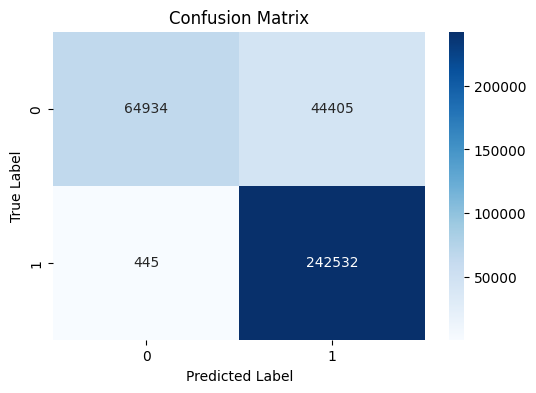

In [16]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_test), yticklabels=set(y_test))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()